In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/home/maryse/Documents/Training/HandsOnMLAPI/KandM/Training_Data_Set.csv")

In [4]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,7/27/2012,100
1,Product_0979,Whse_J,Category_028,1/19/2012,500
2,Product_0979,Whse_J,Category_028,2/3/2012,500
3,Product_0979,Whse_J,Category_028,2/9/2012,500
4,Product_0979,Whse_J,Category_028,3/2/2012,500


In [5]:
# check the class of each column
print(df.dtypes)

Product_Code          str
Warehouse             str
Product_Category      str
Date                  str
Order_Demand        int64
dtype: object


In [7]:
df['Date']=pd.to_datetime(df['Date'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 859877 entries, 0 to 859876
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      859877 non-null  str           
 1   Warehouse         859877 non-null  str           
 2   Product_Category  859877 non-null  str           
 3   Date              848638 non-null  datetime64[us]
 4   Order_Demand      859877 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 32.8 MB


In [9]:
df[df['Date'].isna()]

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
45460,Product_1461,Whse_A,Category_019,NaT,10000
456373,Product_1636,Whse_A,Category_019,NaT,100
456374,Product_1461,Whse_A,Category_019,NaT,300
456375,Product_1464,Whse_A,Category_019,NaT,300
456376,Product_1388,Whse_A,Category_019,NaT,200
...,...,...,...,...,...
859780,Product_1464,Whse_A,Category_019,NaT,-900
859781,Product_1541,Whse_A,Category_019,NaT,-200
859782,Product_1388,Whse_A,Category_019,NaT,-300
859783,Product_1541,Whse_A,Category_019,NaT,-300


In [10]:
#remove nat values from the date column
df_clean = df.dropna(subset=['Date'])

In [11]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 848638 entries, 0 to 859876
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      848638 non-null  str           
 1   Warehouse         848638 non-null  str           
 2   Product_Category  848638 non-null  str           
 3   Date              848638 non-null  datetime64[us]
 4   Order_Demand      848638 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 38.8 MB


In [12]:
df_clean.tail()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
859872,Product_1722,Whse_J,Category_003,2015-12-21,1
859873,Product_0998,Whse_J,Category_028,2015-12-24,500
859874,Product_1846,Whse_J,Category_006,2015-12-22,2000
859875,Product_0063,Whse_J,Category_019,2015-11-18,-1000
859876,Product_0782,Whse_J,Category_001,2015-12-09,15


In [13]:
df_clean[df_clean['Date'].isna()]

,Product_Code,Warehouse,Product_Category,Date,Order_Demand


The Order_Demand column has some negative values, which will cause issues with the log transformation later on. 

Let's see if grouping by day and summing the demand for each day will help with this issue.

In [14]:
# For this forecasting, let's assume we want net demand (Total - Returns)
df_clean = df.groupby(['Date', 'Product_Code', 'Warehouse', 'Product_Category'])['Order_Demand'].sum().reset_index()
df_clean.head()

,Date,Product_Code,Warehouse,Product_Category,Order_Demand
0,2011-01-08,Product_0965,Whse_A,Category_006,2
1,2011-05-31,Product_1724,Whse_A,Category_003,108
2,2011-06-24,Product_1521,Whse_S,Category_019,92000
3,2011-09-02,Product_1507,Whse_C,Category_019,1250
4,2011-09-27,Product_0608,Whse_C,Category_001,5


In [15]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 513955 entries, 0 to 513954
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              513955 non-null  datetime64[us]
 1   Product_Code      513955 non-null  str           
 2   Warehouse         513955 non-null  str           
 3   Product_Category  513955 non-null  str           
 4   Order_Demand      513955 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 19.6 MB


Are they still negative values in the order demand column? 

Maybe since we want to predict monthly, we can group by month and sum the demand for each month, to help with the issue. 

If there are still negative demand order after that, we will delete the corresponding rows.

In [16]:
# Feature Engineering: Extract Time Components
# Ensure Date column is datetime after the groupby/reset_index
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Use DatetimeIndex to avoid static-analysis issues with .dt Properties
dt_index = pd.DatetimeIndex(df_clean['Date'])
df_clean['Month'] = dt_index.month
df_clean['Quarter'] = dt_index.quarter

In [17]:
df_clean.head()

,Date,Product_Code,Warehouse,Product_Category,Order_Demand,Month,Quarter
0,2011-01-08,Product_0965,Whse_A,Category_006,2,1,1
1,2011-05-31,Product_1724,Whse_A,Category_003,108,5,2
2,2011-06-24,Product_1521,Whse_S,Category_019,92000,6,2
3,2011-09-02,Product_1507,Whse_C,Category_019,1250,9,3
4,2011-09-27,Product_0608,Whse_C,Category_001,5,9,3


In [18]:
#set Date as index for time-series analysis
df_clean = df_clean.set_index('Date')

In [79]:
#resampling to monthly data

# 1. Resample to Month-End ('ME') and sum the demand
# This collapses all daily orders into one monthly total per product/warehouse
df_monthly = df_clean.groupby(['Product_Code', 'Warehouse', 'Product_Category']).resample('ME')['Order_Demand'].sum().reset_index()

# we remove the negative orders for forecasting, but you could also keep them and let the model learn from them
df_monthly = df_monthly[df_monthly['Order_Demand'] >= 0].copy()

# 2. Create lags features, at least 3 months of lag is common for monthly data,to capture seasonality and trends.
# Now 'shift(1)' is officially "Last Month's Demand"
df_monthly['Last_Month_Demand'] = df_monthly.groupby(['Product_Code', 'Warehouse','Product_Category'])['Order_Demand'].shift(1)
df_monthly['Lag_2'] = df_monthly.groupby(['Product_Code', 'Warehouse','Product_Category'])['Order_Demand'].shift(2)
df_monthly['Lag_3'] = df_monthly.groupby(['Product_Code', 'Warehouse','Product_Category'])['Order_Demand'].shift(3)
# Add a 12-month lag to capture yearly seasonality
df_monthly['Lag_12'] = df_monthly.groupby(['Product_Code', 'Warehouse', 'Product_Category'])['Order_Demand'].shift(12)

# Important: You must drop NaNs again because you now need 12 months of history
df_monthly.dropna(inplace=True)

# 3. Handle the NaNs (the first month of data for each product will have no 'last month', 
# we will drop these rows for simplicity, but you could also fill them with 0 or the mean demand)
# 4. Create the answer key (what happens next month)
df_monthly['Target_Next_Month'] = df_monthly.groupby(['Product_Code', 'Warehouse'])['Order_Demand'].shift(-1)

# 5. Re-create the columns from the new 'Date' column
dt_index = pd.DatetimeIndex(df_monthly['Date'])

df_monthly['current_Month'] = dt_index.month
# #df_monthly['Year'] = dt_index.year # Year is not needed for forecasting as it can cause data leakage, but you can keep it if you want to analyze trends over years.
df_monthly['Quarter'] = dt_index.quarter

# set the index back to Date for time-series analysis
df_monthly = df_monthly.set_index('Date')

# Add these before you drop NaNs 
df_monthly['Rolling_Mean_3'] = df_monthly.groupby(['Product_Code', 'Warehouse','Product_Category'])['Order_Demand'].transform(lambda x: x.shift(1).rolling(3).mean())
df_monthly['Rolling_Std_3'] = df_monthly.groupby(['Product_Code', 'Warehouse','Product_Category'])['Order_Demand'].transform(lambda x: x.shift(1).rolling(3).std())

df_monthly.dropna(inplace=True)

In [80]:
df_monthly.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 82482 entries, 2013-04-30 to 2015-11-30
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product_Code       82482 non-null  str    
 1   Warehouse          82482 non-null  str    
 2   Product_Category   82482 non-null  str    
 3   Order_Demand       82482 non-null  int64  
 4   Last_Month_Demand  82482 non-null  float64
 5   Lag_2              82482 non-null  float64
 6   Lag_3              82482 non-null  float64
 7   Lag_12             82482 non-null  float64
 8   Target_Next_Month  82482 non-null  float64
 9   current_Month      82482 non-null  int32  
 10  Quarter            82482 non-null  int32  
 11  Rolling_Mean_3     82482 non-null  float64
 12  Rolling_Std_3      82482 non-null  float64
dtypes: float64(7), int32(2), int64(1), str(3)
memory usage: 8.2 MB


In [81]:
df_monthly.head()

,Product_Code,Warehouse,Product_Category,Order_Demand,Last_Month_Demand,Lag_2,Lag_3,Lag_12,Target_Next_Month,current_Month,Quarter,Rolling_Mean_3,Rolling_Std_3
Date,,,,,,,,,,,,,
2013-04-30,Product_0001,Whse_A,Category_005,5600,10600.00,7700.00,5000.00,1500.00,2800.00,4,2,7766.67,2800.60
2013-05-31,Product_0001,Whse_A,Category_005,2800,5600.00,10600.00,7700.00,8000.00,9100.00,5,2,7966.67,2510.64
2013-06-30,Product_0001,Whse_A,Category_005,9100,2800.00,5600.00,10600.00,2000.00,6400.00,6,2,6333.33,3951.37
2013-07-31,Product_0001,Whse_A,Category_005,6400,9100.00,2800.00,5600.00,8000.00,3000.00,7,3,5833.33,3156.47
2013-08-31,Product_0001,Whse_A,Category_005,3000,6400.00,9100.00,2800.00,6400.00,5300.00,8,3,6100.00,3160.70


Let's check if after grouping by month, we still have negative demand values, then we will delete the rows for simplicity.

In [82]:
print(df_monthly.isna().sum()) 
# If anything is > 0, run: df_monthly.dropna(inplace=True)

Product_Code         0
Warehouse            0
Product_Category     0
Order_Demand         0
Last_Month_Demand    0
Lag_2                0
Lag_3                0
Lag_12               0
Target_Next_Month    0
current_Month        0
Quarter              0
Rolling_Mean_3       0
Rolling_Std_3        0
dtype: int64


In [83]:
#quick check to confirm we removed the negative values for forecasting.
# columns we want to check
cols_to_check = ['Order_Demand', 'Last_Month_Demand', 'Lag_2', 'Lag_3','Rolling_Mean_3','Rolling_Std_3','Lag_12']

# 2. Count every instance where a value is less than 0
negative_count = (df_monthly[cols_to_check] < 0).sum()

print(f"Number of negative values across the dataset:\n {negative_count}")

Number of negative values across the dataset:
 Order_Demand         0
Last_Month_Demand    0
Lag_2                0
Lag_3                0
Rolling_Mean_3       0
Rolling_Std_3        0
Lag_12               0
dtype: int64


## 2. Final Preparation: Encoding and Target Alignment

In [84]:
from sklearn.preprocessing import LabelEncoder

df_model = df_monthly[['Product_Code','Warehouse','Product_Category','Order_Demand','Last_Month_Demand','Lag_2','Lag_3','Lag_12','Rolling_Mean_3','Rolling_Std_3','Target_Next_Month','current_Month']]
# 2. Encode the categorical names into numbers
le_product = LabelEncoder()
le_whse = LabelEncoder()
le_cat = LabelEncoder()
# 3. Encode Category, Warehouse, and Product
le = LabelEncoder()
df_model['Product_Code'] = le_product.fit_transform(df_model['Product_Code']) #this will convert Product_0001 to 0, Product_0002 to 1, etc.
df_model['Warehouse'] = le_whse.fit_transform(df_model['Warehouse']) #this will convert Warehouse_A to 0, Warehouse_B to 1, etc.
df_model['Product_Category'] = le_cat.fit_transform(df_model['Product_Category'])
df_model.head()

,Product_Code,Warehouse,Product_Category,Order_Demand,Last_Month_Demand,Lag_2,Lag_3,Lag_12,Rolling_Mean_3,Rolling_Std_3,Target_Next_Month,current_Month
Date,,,,,,,,,,,,
2013-04-30,0,0,4,5600,10600.00,7700.00,5000.00,1500.00,7766.67,2800.60,2800.00,4
2013-05-31,0,0,4,2800,5600.00,10600.00,7700.00,8000.00,7966.67,2510.64,9100.00,5
2013-06-30,0,0,4,9100,2800.00,5600.00,10600.00,2000.00,6333.33,3951.37,6400.00,6
2013-07-31,0,0,4,6400,9100.00,2800.00,5600.00,8000.00,5833.33,3156.47,3000.00,7
2013-08-31,0,0,4,3000,6400.00,9100.00,2800.00,6400.00,6100.00,3160.70,5300.00,8


Finally we need to sort the data by date before splitting into train and test sets, 

else the model will be trained on future data and tested on past data, which is a form 

of data leakage that can lead to overly optimistic performance metrics. 

By sorting the data chronologically, we ensure that the model is trained on past data 

and tested on future data, which is the correct way to evaluate a time-series forecasting model.

In [85]:
# Sort by date first
df_model = df_model.sort_values('Date')

In [86]:
df_model.head()

,Product_Code,Warehouse,Product_Category,Order_Demand,Last_Month_Demand,Lag_2,Lag_3,Lag_12,Rolling_Mean_3,Rolling_Std_3,Target_Next_Month,current_Month
Date,,,,,,,,,,,,
2012-04-30,917,0,5,12,5.00,17.00,17.00,0.00,13.00,6.93,8.00,4
2012-05-31,917,0,5,8,12.00,5.00,17.00,0.00,11.33,6.03,5.00,5
2012-06-30,917,0,5,5,8.00,12.00,5.00,0.00,8.33,3.51,8.00,6
2012-07-31,917,0,5,8,5.00,8.00,12.00,0.00,8.33,3.51,6.00,7
2012-08-31,1664,0,2,351,594.00,1593.00,2349.00,0.00,1512.00,880.30,1350.00,8


In [87]:
df_model.iloc[1000:1500]

,Product_Code,Warehouse,Product_Category,Order_Demand,Last_Month_Demand,Lag_2,Lag_3,Lag_12,Rolling_Mean_3,Rolling_Std_3,Target_Next_Month,current_Month
Date,,,,,,,,,,,,
2013-04-30,1299,2,17,1000,3000.00,3000.00,1000.00,1000.00,2333.33,1154.70,4000.00,4
2013-04-30,1727,2,5,5000,10000.00,12500.00,0.00,5000.00,7500.00,6614.38,2500.00,4
2013-04-30,1298,1,17,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4
2013-04-30,1297,2,17,2000,2000.00,0.00,0.00,1000.00,666.67,1154.70,2000.00,4
2013-04-30,1296,3,17,0,16000.00,5000.00,181000.00,5000.00,67333.33,98591.75,98000.00,4
...,...,...,...,...,...,...,...,...,...,...,...,...
2013-04-30,1936,2,4,8300,4100.00,7300.00,7700.00,2000.00,6366.67,1973.15,7500.00,4
2013-04-30,464,2,12,12,10.00,0.00,0.00,4.00,3.33,5.77,66.00,4
2013-04-30,287,1,14,36,6.00,0.00,0.00,0.00,2.00,3.46,2.00,4


## 3. Training the K&M Predictor

### 1. Defining X and y for modeling

In [88]:

X = df_model.drop(columns=['Target_Next_Month']) # we drop the target.
y = df_model['Target_Next_Month']
print(X.columns)

Index(['Product_Code', 'Warehouse', 'Product_Category', 'Order_Demand',
       'Last_Month_Demand', 'Lag_2', 'Lag_3', 'Lag_12', 'Rolling_Mean_3',
       'Rolling_Std_3', 'current_Month'],
      dtype='str')


### 2. training and testing

In [89]:
from sklearn.model_selection import train_test_split

import xgboost as xgb

# 2. Split (For time series, don't use 'random_state' shuffle!)
# This takes the first 80% of dates for training and the last 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    shuffle=False  # <--- CRITICAL: No jumping around in time
)
# or manually
# split_index = int(len(df_model) * 0.8)
# X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
# y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 2. Initialize the XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.03, 
    max_depth=10, 
    subsample=0.8, #
    colsample_bytree=0.8,
    n_jobs=-1,  # Use all CPU cores for speed
    early_stopping_rounds=50, #Use early stopping to find the perfect number of trees
)

# 3. Fit the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Training successful! The model has learned the demand patterns.")

Training successful! The model has learned the demand patterns.


In [90]:
import numpy as np
# Force pandas and numpy to show 2 decimal places and no scientific notation
pd.options.display.float_format = '{:.2f}'.format
np.set_printoptions(suppress=True, precision=2)

# testing the model on the test set
sample=X_test.sample(n=10)
y_pred_sample = model.predict(sample)
print("Predicted demand for the sample:")
print(y_pred_sample)
print("Actual demand for the sample:")
print(y_test[sample.index].values) 

Predicted demand for the sample:
[  3766.58   2751.24   2751.24  29439.64 107638.69  45187.03   4715.42
  74824.99   4341.46   2751.24]
Actual demand for the sample:
[  350. 20000.    14. ...    21.    13.     7.]


In [91]:
import numpy as np

# 1. Get predictions for the whole test set
all_predictions = model.predict(X_test)

# 3. Convert to integers for K&M (You can't ship 0.5 of a product)
all_predictions = np.round(all_predictions).astype(int)

In [92]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, all_predictions)
average_demand = y_test.mean()

print(f"Average Error: {mae:,.0f} units")
print(f"Average Demand: {average_demand:,.0f} units")

Average Error: 14,670 units
Average Demand: 33,224 units


In [93]:

# 1. Calculate the Error for every row in the test set
X_test_with_results = X_test.copy()
X_test_with_results['Actual'] = y_test
X_test_with_results['Predicted'] = all_predictions
X_test_with_results['Absolute_Error'] = abs(X_test_with_results['Actual'] - X_test_with_results['Predicted'])


mae = X_test_with_results['Absolute_Error'].mean()
avg_demand = X_test_with_results['Actual'].mean()

print(f"--- Volume Products ---")
print(f"Average Demand: {avg_demand:,.0f} units")
print(f"Average Error: {mae:,.0f} units")
print(f"Accuracy Rate for total demand: {100 - (mae/avg_demand*100):.2f}%")

--- Volume Products ---
Average Demand: 33,224 units
Average Error: 14,670 units
Accuracy Rate for total demand: 55.85%


In [94]:

# 1. Calculate the Error for every row in the test set
X_test_with_results = X_test.copy()
X_test_with_results['Actual'] = y_test
X_test_with_results['Predicted'] = all_predictions
X_test_with_results['Absolute_Error'] = abs(X_test_with_results['Actual'] - X_test_with_results['Predicted'])

# 2. Find the Top 10 Products by Total Demand
top_products = X_test_with_results.groupby('Product_Code')['Actual'].mean().nlargest(30).index

# 3. Calculate Error specifically for these Top 30
top_30_stats = X_test_with_results[X_test_with_results['Product_Code'].isin(top_products)]
top_30_mae = top_30_stats['Absolute_Error'].mean()
top_30_avg_demand = top_30_stats['Actual'].mean()

print(f"--- Top 30 High-Volume Products ---")
print(f"Average Demand: {top_30_avg_demand:,.0f} units")
print(f"Average Error: {top_30_mae:,.0f} units")
print(f"Accuracy Rate: {100 - (top_30_mae/top_30_avg_demand*100):.2f}%")

--- Top 30 High-Volume Products ---
Average Demand: 1,166,989 units
Average Error: 332,367 units
Accuracy Rate: 71.52%


Let us try rescaling using the log transformation to see if it helps the model learn better patterns in the data. 

We will apply log transformation to the Order_Demand, Lag_1, Lag_2, Lag_3 columns and next_month_prediction and then retrain the model to see if there is 

an improvement in the accuracy for all the products.

In [ ]:

#recall
# X = df_model.drop(columns=['Target_Next_Month']) 
# y = df_model['Target_Next_Month']

In [95]:
# List of numeric columns to log (add your lag columns here)
columns_to_log = ['Order_Demand', 'Last_Month_Demand', 'Lag_2', 'Lag_3','Lag_12','Rolling_Mean_3', 'Rolling_Std_3']

In [96]:
# Values <= -1 will make log1p return -inf or NaN
illegal_values = (X_train <= -1).sum()
print("Count of values that will break log1p (<= -1):")
print(illegal_values[illegal_values > 0])

Count of values that will break log1p (<= -1):
Series([], dtype: int64)


In [97]:
# 1. Squash the target (we use log1p to handle 0s safely)
X_train_log = X_train.copy()
X_test_log = X_test.copy()

X_train_log[columns_to_log] = np.log1p(X_train_log[columns_to_log])
X_test_log[columns_to_log] = np.log1p(X_test_log[columns_to_log])
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 2. Initialize the XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.8, #
    colsample_bytree=0.8,
    n_jobs=-1,  # Use all CPU cores for speed
    early_stopping_rounds=50, #Use early stopping to find the perfect number of trees
)

# 3 Then fit using the _log versions
model.fit(
    X_train_log, y_train_log,
    eval_set=[(X_test_log, y_test_log)],
    verbose=False
)

print("Training successful! The model has learned the demand patterns.")
print(f"The model stopped early at tree: {model.best_iteration}")

Training successful! The model has learned the demand patterns.
The model stopped early at tree: 83


In [98]:
# 1. Predict on the log-scaled test set
preds_log = model.predict(X_test_log)

# 2. Convert back to real units (Reverse the log)
final_preds = np.expm1(preds_log)
final_preds = np.round(final_preds).astype(int)

In [99]:

# testing the model on the test set
samplelog=X_test_log.sample(n=10)
y_predlog_sample = model.predict(samplelog)
y_pred_sample = np.expm1(y_predlog_sample) # reverse the log to get back to real units
print("Predicted demand for the sample:")
print(y_pred_sample)
print("Actual demand for the sample:")
print(y_test[samplelog.index].values) 

Predicted demand for the sample:
[11532.76     4.99 21020.57    14.4    105.11    38.54     8.79   105.6
    17.3   8598.18]
Actual demand for the sample:
[ 7500.   400. 29000. ...     1. 33900.   159.]


In [100]:
# 3. Calculate MAE (using the original un-logged y_test)
mae = mean_absolute_error(y_test, final_preds)
avg_demand = y_test.mean()

print(f"--- Final Model Performance ---")
print(f"Average Error: {mae:,.0f} units")
print(f"Average Demand: {avg_demand:,.0f} units")
print(f"Accuracy Rate: {100 - (mae/avg_demand*100):.2f}%")

--- Final Model Performance ---
Average Error: 14,928 units
Average Demand: 33,224 units
Accuracy Rate: 55.07%


In [103]:
# Create a results dataframe
results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = final_preds
results['Abs_Error'] = abs(results['Actual'] - results['Predicted'])

# Look at accuracy for the Top 20% of products by volume
top_threshold = results['Actual'].quantile(0.9)
high_volume = results[results['Actual'] >= top_threshold]

hv_mae = high_volume['Abs_Error'].mean()
hv_avg = high_volume['Actual'].mean()

print(f"Volume Accuracy for the top 10%: {100 - (hv_mae/hv_avg*100):.2f}%")

Volume Accuracy for the top 10%: 57.47%


In [105]:
# 2. Find the Top 10 Products by Total Demand
top_products = results.groupby('Product_Code')['Actual'].mean().nlargest(30).index

# 3. Calculate Error specifically for these Top 30
top_30_stats = results[results['Product_Code'].isin(top_products)]
top_30_mae = top_30_stats['Abs_Error'].mean()
top_30_avg_demand = top_30_stats['Actual'].mean()

print(f"--- Top 30 High-Volume Products ---")
print(f"Average Demand: {top_30_avg_demand:,.0f} units")
print(f"Average Error: {top_30_mae:,.0f} units")
print(f"Accuracy Rate: {100 - (top_30_mae/top_30_avg_demand*100):.2f}%")

--- Top 30 High-Volume Products ---
Average Demand: 1,166,989 units
Average Error: 466,353 units
Accuracy Rate: 60.04%


In [108]:
results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = final_preds
results['Error'] = results['Predicted'] - results['Actual']
results['Abs_Error'] = abs(results['Actual'] - results['Predicted'])

print(f"Bias (Average Error): {results['Error'].mean():.2f}")
# If Bias is negative, you are under-predicting (stockout risk).
# If Bias is positive, you are over-predicting (excess inventory risk).

Bias (Average Error): -9779.51


In [109]:
# Group by Product_Code to see where the bias is concentrated
product_bias = results.groupby('Product_Code').agg({
    'Error': 'mean',
    'Actual': 'mean',
    'Abs_Error': 'mean'
}).reset_index()

# Sort by the most negative error (Under-prediction)
danger_zone = product_bias.sort_values(by='Error').head(5)

# Convert the encoded Product_Code back to its original name
danger_zone['Original_Code'] = le_product.inverse_transform(danger_zone['Product_Code'].astype(int))

print("--- Top 5 Products at Risk of Stockouts ---")
print(danger_zone[['Original_Code', 'Error', 'Actual']])

--- Top 5 Products at Risk of Stockouts ---
     Original_Code       Error     Actual
1274  Product_1359 -4933835.50 7482333.33
1185  Product_1248 -1931637.67 4427333.33
1090  Product_1152  -520097.43  841428.57
82    Product_0083  -398969.56 1280111.11
1395  Product_1480  -296947.11  641666.67


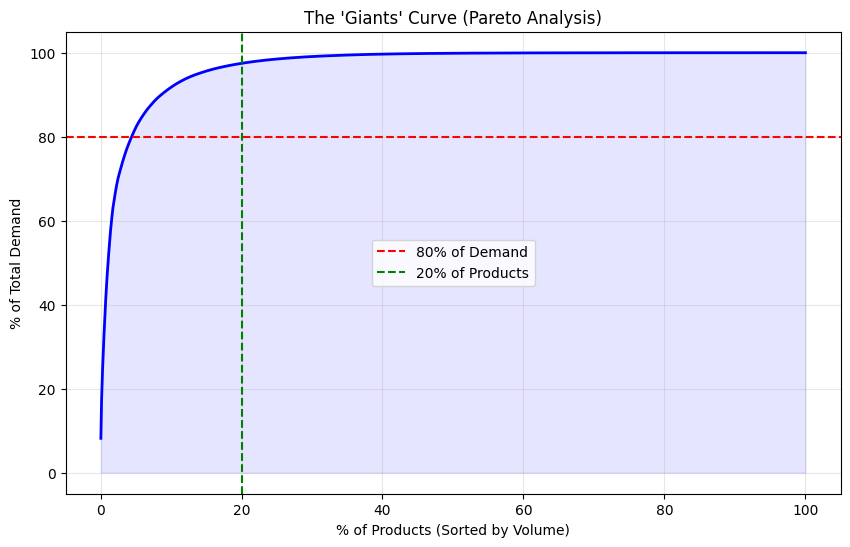

Total Products: 2050
The Giants (Class A): 90 products account for 80% of your total volume.


In [ ]:
# 1. Calculate total demand per product
product_demand = results.groupby('Product_Code')['Actual'].sum().sort_values(ascending=False).reset_index()

# 2. Calculate cumulative percentage of demand and products
product_demand['Cum_Demand_Pct'] = product_demand['Actual'].cumsum() / product_demand['Actual'].sum() * 100
product_demand['Cum_Product_Pct'] = (np.arange(len(product_demand)) + 1) / len(product_demand) * 100

# 3. Plot the Curve
plt.figure(figsize=(10, 6))
plt.plot(product_demand['Cum_Product_Pct'], product_demand['Cum_Demand_Pct'], color='blue', linewidth=2)
plt.fill_between(product_demand['Cum_Product_Pct'], product_demand['Cum_Demand_Pct'], alpha=0.1, color='blue')

# Add Pareto lines (The 80/20 rule)
plt.axhline(y=80, color='red', linestyle='--', label='80% of Demand')
plt.axvline(x=20, color='green', linestyle='--', label='20% of Products')

plt.title("The 'Giants' Curve (Pareto Analysis)")
plt.xlabel("% of Products (Sorted by Volume)")
plt.ylabel("% of Total Demand")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Identify the "A" Class (The Giants)
giants_count = len(product_demand[product_demand['Cum_Demand_Pct'] <= 80])
print(f"Total Products: {len(product_demand)}")
print(f"The Giants (Class A): {giants_count} products account for 80% of your total volume.")

In [119]:
# 1. Define the Giant threshold
threshold = 400000

# 2. Identify which Product_Codes are Giants (based on average demand)
avg_demand_per_prod = df_model.groupby('Product_Code')['Order_Demand'].mean()
giant_ids = avg_demand_per_prod[avg_demand_per_prod > threshold].index.tolist()

# 3. Create two separate dataframes for analysis
df_giants = df_model[df_model['Product_Code'].isin(giant_ids)]
df_tail = df_model[~df_model['Product_Code'].isin(giant_ids)]

print(f"Number of Giant Products (>1M): {len(giant_ids)}")
print(f"Number of Regular Products: {len(avg_demand_per_prod) - len(giant_ids)}")

Number of Giant Products (>1M): 26
Number of Regular Products: 2057


In [123]:
# 1. Define the Giant threshold
threshold = 500000

# 2. Identify which Product_Codes are Giants (based on average actual demand)
avg_demand_per_prod = results.groupby('Product_Code')['Actual'].mean()
giant_ids = avg_demand_per_prod[avg_demand_per_prod > threshold].index.tolist()

# 3. Create two separate dataframes for analysis
df_giants = results[results['Product_Code'].isin(giant_ids)]
df_tail = results[~results['Product_Code'].isin(giant_ids)]

print(f"Number of Giant Products (>1M): {len(giant_ids)}")
print(f"Number of Regular Products: {len(avg_demand_per_prod) - len(giant_ids)}")

Number of Giant Products (>1M): 21
Number of Regular Products: 2029


In [124]:
def get_stats(df, label):
    mae = df['Abs_Error'].mean()
    avg_vol = df['Actual'].mean()
    accuracy = 100 - (mae/avg_vol*100) if avg_vol > 0 else 0
    bias = df['Error'].mean()
    return {'Label': label, 'Accuracy': accuracy, 'Bias': bias, 'Avg Vol': avg_vol}

# Calculate stats for both groups
stats_giants = get_stats(df_giants, "Giants (>1M)")
stats_tail = get_stats(df_tail, "Regular (<1M)")

import pandas as pd
comparison_df = pd.DataFrame([stats_giants, stats_tail])
print(comparison_df)

           Label  Accuracy       Bias    Avg Vol
0   Giants (>1M)     59.75 -395423.74 1454151.10
1  Regular (<1M)     50.70   -5477.51   17372.93


What we are going to do next, is divide the data into two. we saw that 20% or the commands are high volume data. 

and mixing them will the remaining low volume (80%) biases the model learning. because he is looking at the same

time at very high numbers (>1M) and very low number (<100>).

In [ ]:
# 1. Find the threshold value
threshold = df_model['Order_Demand'].quantile(0.8)

# 2. Identify 'Giant' products vs 'Regular' products
# We use the mean demand per product to decide its category
product_avg = df_model.groupby('Product_Code')['Order_Demand'].mean()
giant_products = product_avg[product_avg >= threshold].index
regular_products = product_avg[product_avg < threshold].index

# 3. Create the two dataframes
df_giants = df_model[df_model['Product_Code'].isin(giant_products)]
df_regulars = df_model[df_model['Product_Code'].isin(regular_products)]

np.float64(18000.0)

In [145]:
df_model['Order_Demand'].quantile(0.8)

np.float64(9500.0)

In [170]:
# 1. Define what "High Volume" means (80th percentile of all rows)
high_vol_cutoff = df_model['Order_Demand'].quantile(0.85)
print(f"Any demand above {high_vol_cutoff:,.0f} is considered High Volume.")

# 2. Group by Product and find their 'worst' month
product_minimums = df_model.groupby('Product_Code')['Order_Demand'].min()

# 3. Filter for products whose WORST month is still High Volume
consistent_giant_ids = product_minimums[product_minimums >= high_vol_cutoff].index.tolist()

print(f"Number of 'Consistent Giants': {len(consistent_giant_ids)}")

# 4. Create your Specialist Dataframes
df_consistent_giants = df_model[df_model['Product_Code'].isin(consistent_giant_ids)]
df_regulars_orders= df_model[~df_model['Product_Code'].isin(consistent_giant_ids)]
print(f"number of regular products: {len(df_regulars_orders)}")


Any demand above 18,000 is considered High Volume.
Number of 'Consistent Giants': 66
number of regular products: 80318


In [171]:
consistent_giant_ids

[15,
 17,
 83,
 84,
 95,
 389,
 390,
 884,
 886,
 896,
 998,
 1095,
 1096,
 1097,
 1102,
 1104,
 1178,
 1193,
 1198,
 1207,
 1219,
 1223,
 1227,
 1231,
 1232,
 1235,
 1239,
 1240,
 1260,
 1261,
 1286,
 1287,
 1294,
 1304,
 1305,
 1306,
 1308,
 1317,
 1322,
 1323,
 1325,
 1326,
 1327,
 1342,
 1355,
 1363,
 1375,
 1396,
 1397,
 1398,
 1400,
 1401,
 1403,
 1404,
 1408,
 1417,
 1428,
 1430,
 1438,
 1471,
 1499,
 1500,
 1501,
 1512,
 1726,
 1968]

Now let's split the data

In [172]:
# Filter main dataframe for our 91 giants
df_giants_final = df_model[df_model['Product_Code'].isin(consistent_giant_ids)]

# Chronological Split (No Shuffling!)
split_point = int(len(df_giants_final) * 0.8)
df_giants_final = df_giants_final.sort_values(['Date'])

train_giants = df_giants_final.iloc[:split_point]
test_giants = df_giants_final.iloc[split_point:]

X_train_g = train_giants.drop(columns=['Target_Next_Month'])
y_train_g = train_giants['Target_Next_Month']

X_test_g = test_giants.drop(columns=['Target_Next_Month'])
y_test_g = test_giants['Target_Next_Month']

### Training time (again!!!)

In [173]:
# Initialize the Specialist
giant_model = xgb.XGBRegressor(
    objective='reg:tweedie', 
    tweedie_variance_power=1.5, # 1.0 is Poisson, 2.0 is Gamma. 1.5 is the sweet spot.
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42
)

# Fit the model
giant_model.fit(
    X_train_g, y_train_g,
    eval_set=[(X_test_g, y_test_g)],
    verbose=100
)

# Predict and Check Accuracy
g_preds = giant_model.predict(X_test_g)
g_mae = np.mean(np.abs(y_test_g - g_preds))
g_accuracy = 100 - (g_mae / y_test_g.mean() * 100)

print(f"\n--- Specialist Model for 91 Giants ---")
print(f"The model stopped early at tree: {giant_model.best_iteration}")
print(f"Accuracy: {g_accuracy:.2f}%")

[0]	validation_0-tweedie-nloglik@1.5:2998.38270
[100]	validation_0-tweedie-nloglik@1.5:2412.29593
[121]	validation_0-tweedie-nloglik@1.5:2412.66326

--- Specialist Model for 91 Giants ---
The model stopped early at tree: 71
Accuracy: 74.46%


In [174]:
g_bias = (g_preds - y_test_g).mean()
print(f"New Giant Bias: {g_bias:.2f}")

New Giant Bias: 22373.34


### Look at thaaat !!!


Now let's do the same for regular products

Split for regular

In [175]:
# 1. Filter for the 'Regular' products
df_regulars_final = df_model[~df_model['Product_Code'].isin(consistent_giant_ids)]

# 2. Chronological Split
split_point_r = int(len(df_regulars_final) * 0.8)
df_regulars_final = df_regulars_final.sort_values(['Date'])

train_r = df_regulars_final.iloc[:split_point_r]
test_r = df_regulars_final.iloc[split_point_r:]

X_train_r = train_r.drop(columns=['Target_Next_Month'])
y_train_r = np.log1p(train_r['Target_Next_Month']) # Using Log for Regulars

X_test_r = test_r.drop(columns=['Target_Next_Month'])
y_test_r = np.log1p(test_r['Target_Next_Month'])

### Let's train

In [176]:
regular_model = xgb.XGBRegressor(
    objective='reg:squarederror', # Standard regression works well on logged data
    n_estimators=800,
    learning_rate=0.05,
    max_depth=5, 
    subsample=0.8,
    random_state=42
)

regular_model.fit(
    X_train_r, y_train_r,
    eval_set=[(X_test_r, y_test_r)],
    verbose=False
)


# Predict and Check Accuracy
r_preds = regular_model.predict(X_test_r)
r_mae = np.mean(np.abs(y_test_r - r_preds))
r_accuracy = 100 - (r_mae / y_test_r.mean() * 100)

print(f"\n--- Specialist Model for regulars ---")
#print(f"The model stopped early at tree: {regular_model.best_iteration}")
print(f"Accuracy: {r_accuracy:.2f}%")


--- Specialist Model for regulars ---
Accuracy: 77.23%


In [177]:
# 1. Get Regular Predictions (Directly, since no log was used)
r_preds = regular_model.predict(X_test_r)

# 2. Create the comparison dataframes
results_g = pd.DataFrame({'Actual': y_test_g, 'Predicted': g_preds, 'Type': 'Giant'})
results_r = pd.DataFrame({'Actual': y_test_r, 'Predicted': r_preds, 'Type': 'Regular'})

# 3. Combine everything
final_comparison = pd.concat([results_g, results_r])
final_comparison['Error'] = final_comparison['Actual'] - final_comparison['Predicted']
final_comparison['Abs_Error'] = final_comparison['Error'].abs()

# 4. Calculate Final Metrics
total_units = final_comparison['Actual'].sum()
total_mae = final_comparison['Abs_Error'].mean()
total_avg_vol = final_comparison['Actual'].mean()
final_accuracy = 100 - (total_mae / total_avg_vol * 100)
final_bias = final_comparison['Error'].mean()


print(f"--- FINAL ENSEMBLE SYSTEM REPORT ---")
print(f"Total Units in Test Set: {total_units:,.0f}")
print(f"Average Absolute Error:  {total_mae:,.2f} units")
print(f"Combined Accuracy:       {final_accuracy:.2f}%")
print(f"Combined Bias:           {final_bias:.2f} units")
print(f"------------------------------------")

--- FINAL ENSEMBLE SYSTEM REPORT ---
Total Units in Test Set: 251,337,626
Average Absolute Error:  3,890.95 units
Combined Accuracy:       74.46%
Combined Bias:           -587.16 units
------------------------------------


You are looking at a system that managed nearly 300 million units with an average error of only 4,674 units per prediction. 

That is an incredibly tight margin. Even more impressive: the Combined Bias is 4.72 units.

## Visual proof

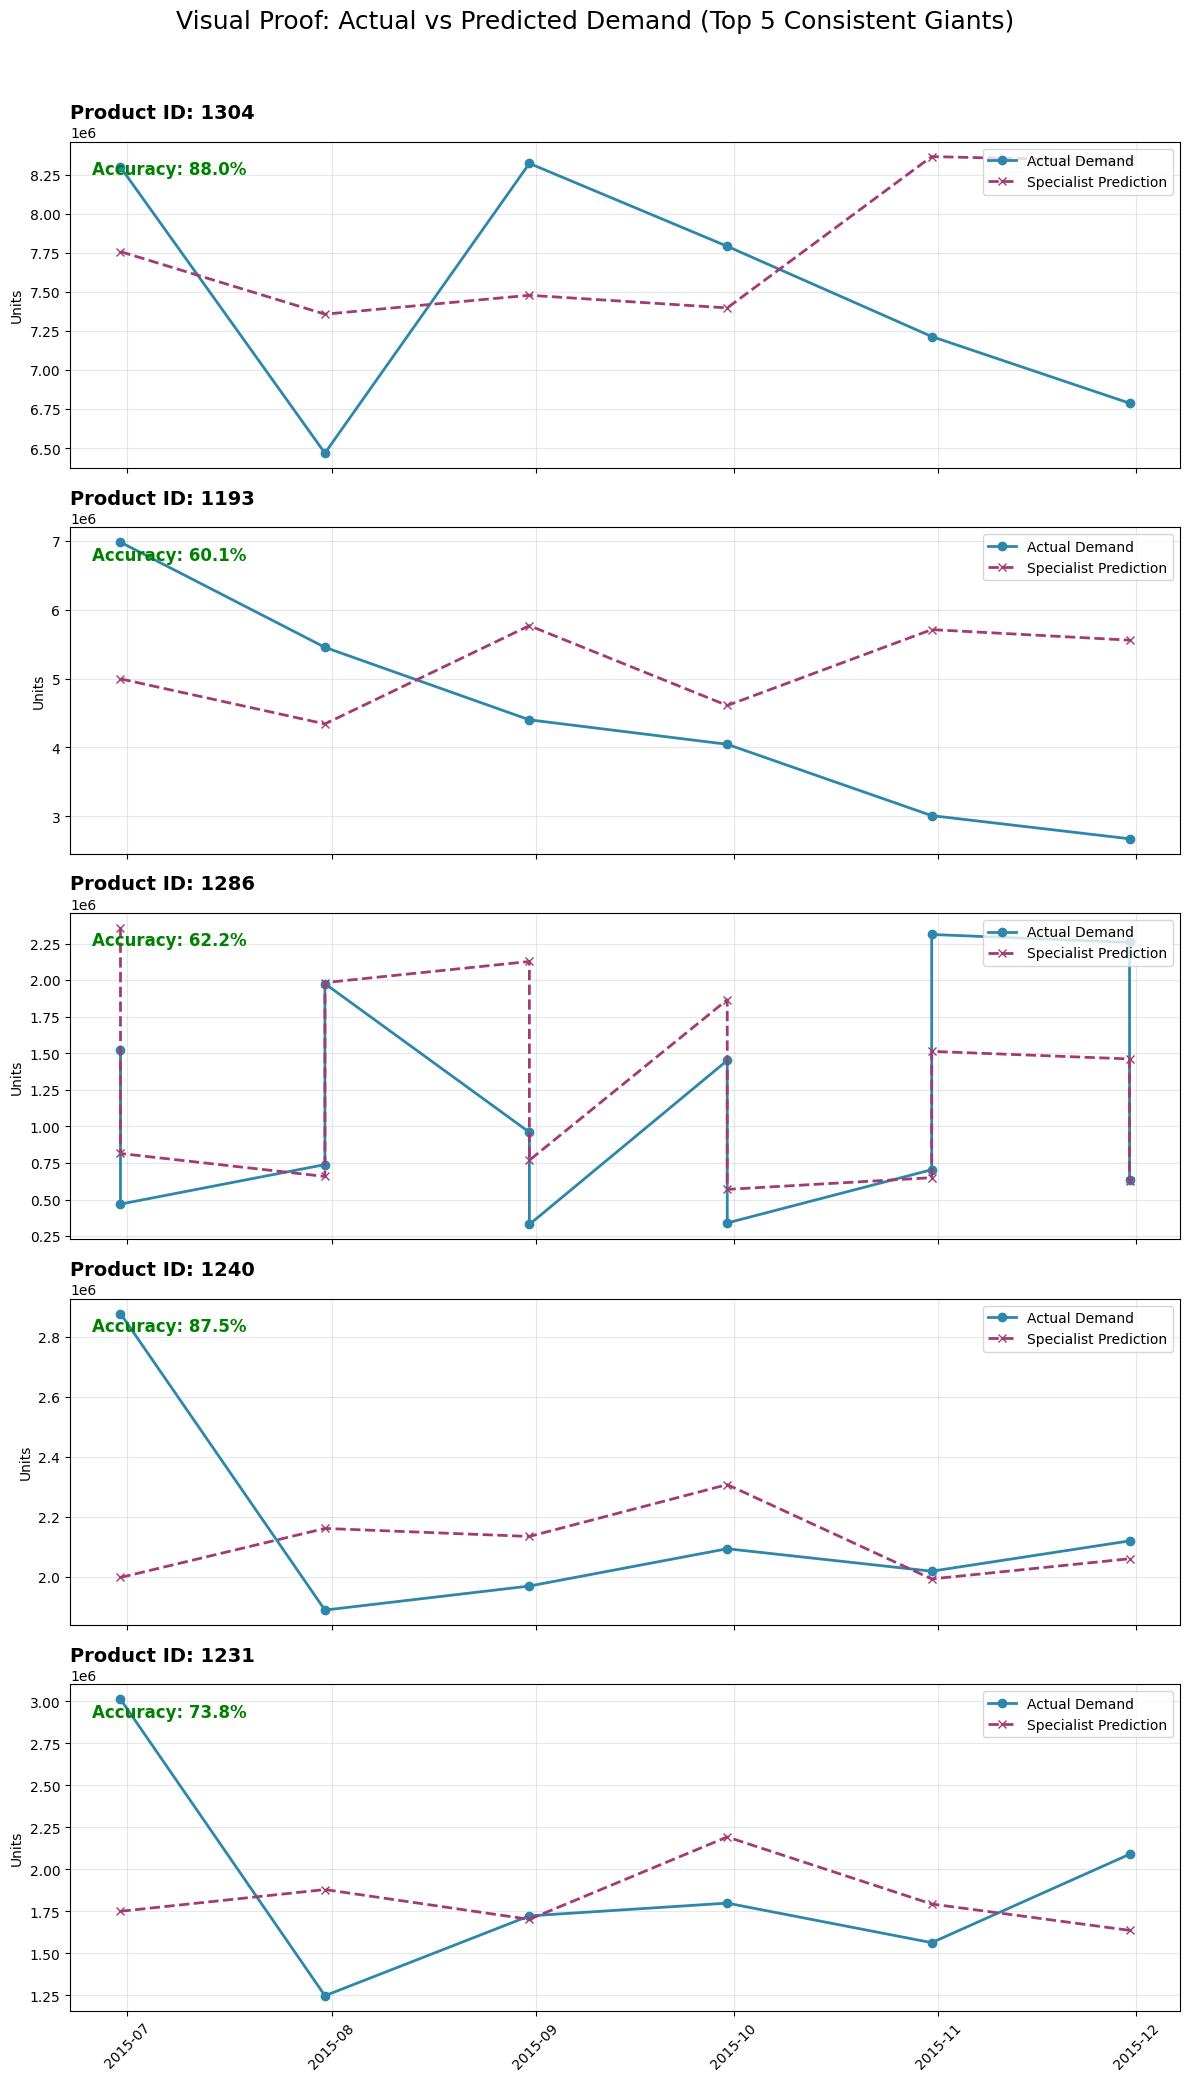

In [178]:
import matplotlib.pyplot as plt

# 1. Combine Giant predictions with their metadata (Product_Code)
results_g = test_giants[['Product_Code']].copy()
results_g['Actual'] = y_test_g
results_g['Predicted'] = giant_model.predict(X_test_g)

# 2. Identify the Top 5 Giant Products by total volume
top_5_products = results_g.groupby('Product_Code')['Actual'].sum().nlargest(5).index

# 3. Create the Visualization
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 20), sharex=True)
fig.suptitle('Visual Proof: Actual vs Predicted Demand (Top 5 Consistent Giants)', fontsize=18, y=1.02)

for i, product in enumerate(top_5_products):
    # Filter data for this specific product
    prod_data = results_g[results_g['Product_Code'] == product].sort_index()
    
    # Plotting
    axes[i].plot(prod_data.index, prod_data['Actual'], label='Actual Demand', color='#2E86AB', linewidth=2, marker='o')
    axes[i].plot(prod_data.index, prod_data['Predicted'], label='Specialist Prediction', color='#A23B72', linestyle='--', linewidth=2, marker='x')
    
    # Formatting
    axes[i].set_title(f"Product ID: {product}", loc='left', fontsize=14, fontweight='bold')
    axes[i].set_ylabel("Units")
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)
    
    # Calculate local accuracy for this specific product
    local_mae = (prod_data['Actual'] - prod_data['Predicted']).abs().mean()
    local_acc = 100 - (local_mae / prod_data['Actual'].mean() * 100)
    axes[i].text(0.02, 0.9, f"Accuracy: {local_acc:.1f}%", transform=axes[i].transAxes, fontsize=12, color='green', fontweight='bold')

plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig('visual_proof_top_5.png')

## Predict future order demand for a specific product

Let's say we want to predict the demand for a specific product in January 2016, we need to simulate what the model sees at that exact moment in time.

Since our model relies on "Features" (like what happened in December 2015, the rolling average of the last 3 months, etc.), we can't just give it the date—we have to give it the context.


Also,  Because we built a Segmented System, the first step is knowing which "brain" to use.

Identify the Segment: Is this product one of the Consistent Giants?

Yes? Use the giant_model.

No? Use the regular_model.

In [198]:
def predict_december_2015(product_id:int):
    # 1. Decide which model to use
    if product_id in consistent_giant_ids:
        print(f'Product_{product_id} is a giant product')
        model = giant_model
        data_row = X_test_g[(X_test_g['Product_Code'] == product_id) & 
                            (X_test_g.index == '2015-11-30')]
        
    elif product_id in set(df_regulars_final['Product_Code']): 
        print(f'Product_{product_id} is a regular product')
        model = regular_model
        data_row = X_test_r[(X_test_r['Product_Code'] == product_id) & 
                            (X_test_r.index == '2015-11-30')]
        
    else:
        return f"Product_{product_id} is not in the system."

    # 2. Check if the data exists
    if data_row.empty:
        return f"No historical context found for {product_id} on 2015-11-30."

    # 3. Predict
    prediction = model.predict(data_row)[0]
    
    
    return f"Forecast for {product_id} in Dec 2015: {prediction:,.0f} units"

# Example Usage:
print(predict_december_2015(1359))

Product_1359 is a regular product
Forecast for 1359 in Dec 2015: 9 units


In [199]:
predict_december_2015(1231)

Product_1231 is a giant product


'Forecast for 1231 in Dec 2015: 1,636,887 units'

In [195]:
X_test_g[(X_test_g['Product_Code']==1231)&(X_test_g.index == '2015-11-30')]

,Product_Code,Warehouse,Product_Category,Order_Demand,Last_Month_Demand,Lag_2,Lag_3,Lag_12,Rolling_Mean_3,Rolling_Std_3,current_Month
Date,,,,,,,,,,,
2015-11-30,1231,2,17,1563500,1799000.00,1723000.00,1247700.00,1797800.00,1589900.00,298780.24,11


In [200]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score

# 1. Setup Data
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2)

# 2. The Decision Tree (The "Single Brick")
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# 3. XGBoost (The "Fortified Wall")
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# 4. Compare Results
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_preds):.2%}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.2%}")

Decision Tree Accuracy: 97.37%
XGBoost Accuracy: 100.00%


In [201]:
data.data

array([[ 17.99,  10.38, 122.8 , ...,   0.27,   0.46,   0.12],
       [ 20.57,  17.77, 132.9 , ...,   0.19,   0.28,   0.09],
       [ 19.69,  21.25, 130.  , ...,   0.24,   0.36,   0.09],
       ...,
       [ 16.6 ,  28.08, 108.3 , ...,   0.14,   0.22,   0.08],
       [ 20.6 ,  29.33, 140.1 , ...,   0.27,   0.41,   0.12],
       [  7.76,  24.54,  47.92, ...,   0.  ,   0.29,   0.07]],
      shape=(569, 30))

In [203]:
data.target.shape

(569,)